--- Q1: Dataset Overview ---
Rows: 1500, Columns: 8
Column Names: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4    

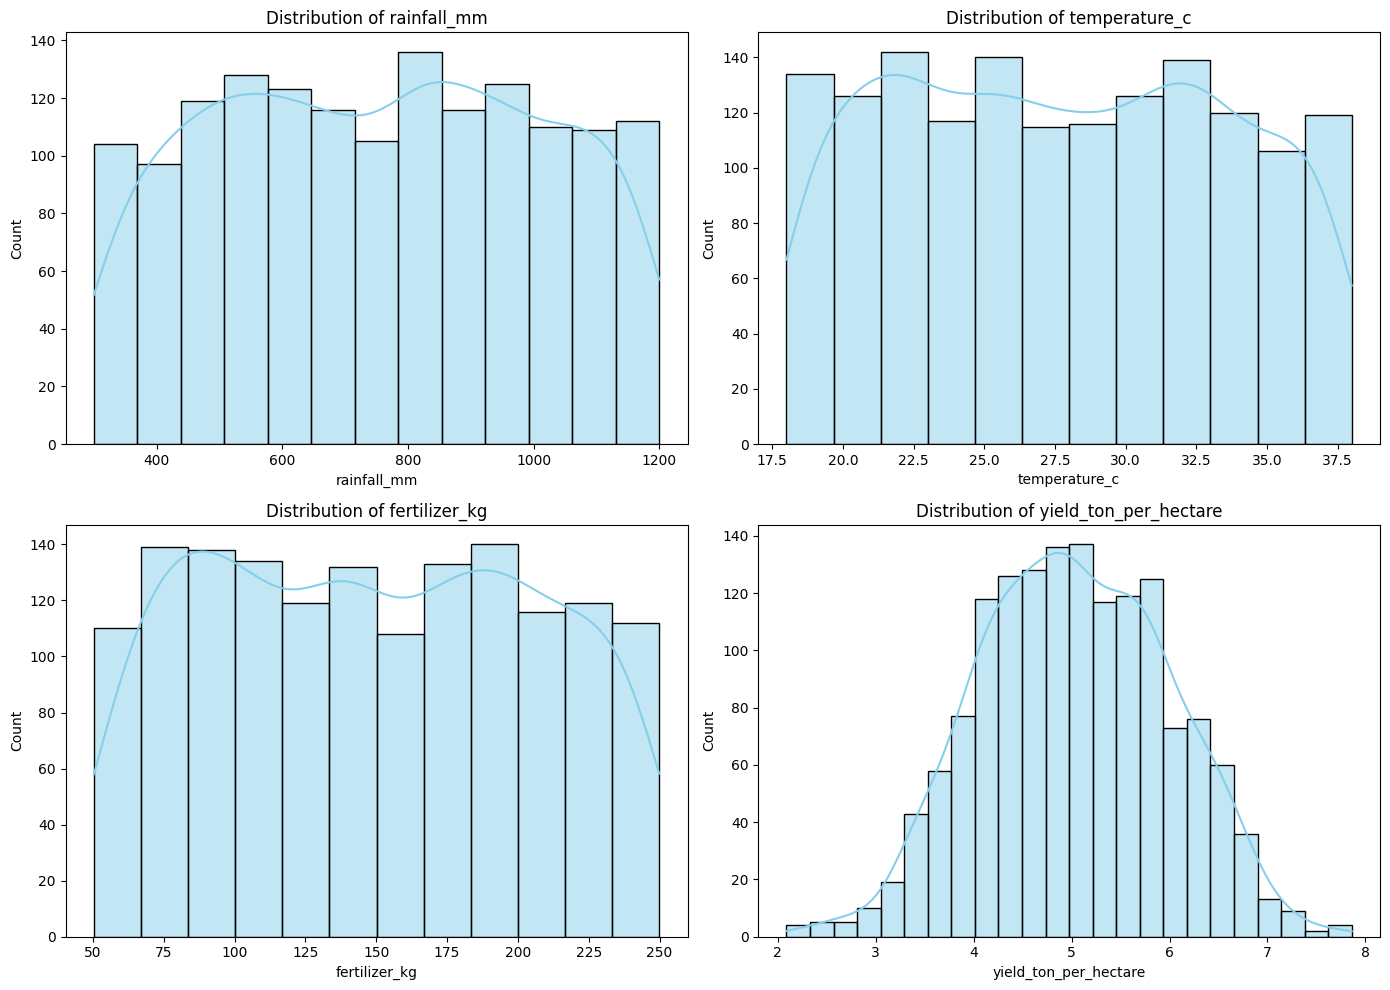



--- Q5: Crop Type Analysis ---
Crop Type Counts:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


/tmp/ipykernel_5781/2647245322.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', order=df['crop_type'].value_counts().index, palette='viridis')


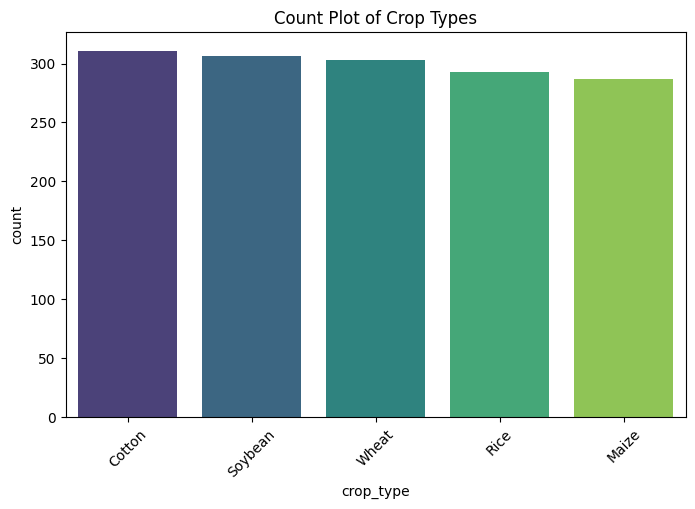



--- Q6: Soil Type Analysis ---
Soil Type Counts:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


/tmp/ipykernel_5781/2647245322.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='soil_type', order=df['soil_type'].value_counts().index, palette='magma')


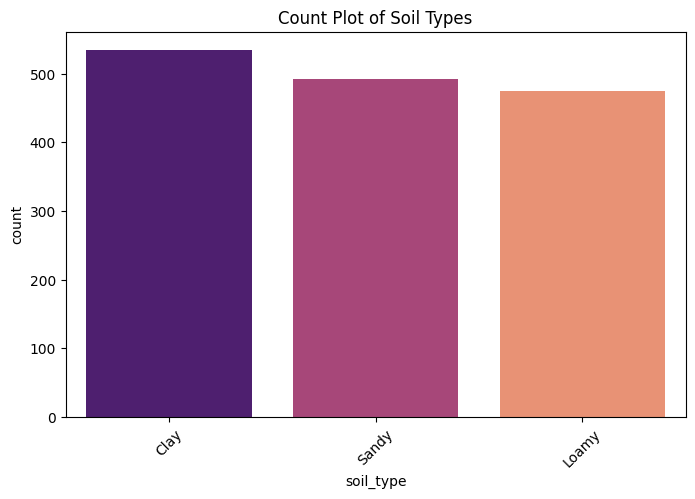



--- Q7: Yield Distribution ---


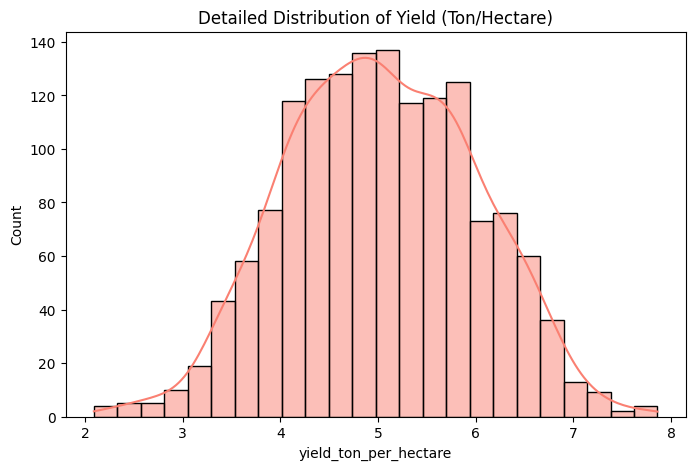



--- Q8: Scatter Plot Analysis ---


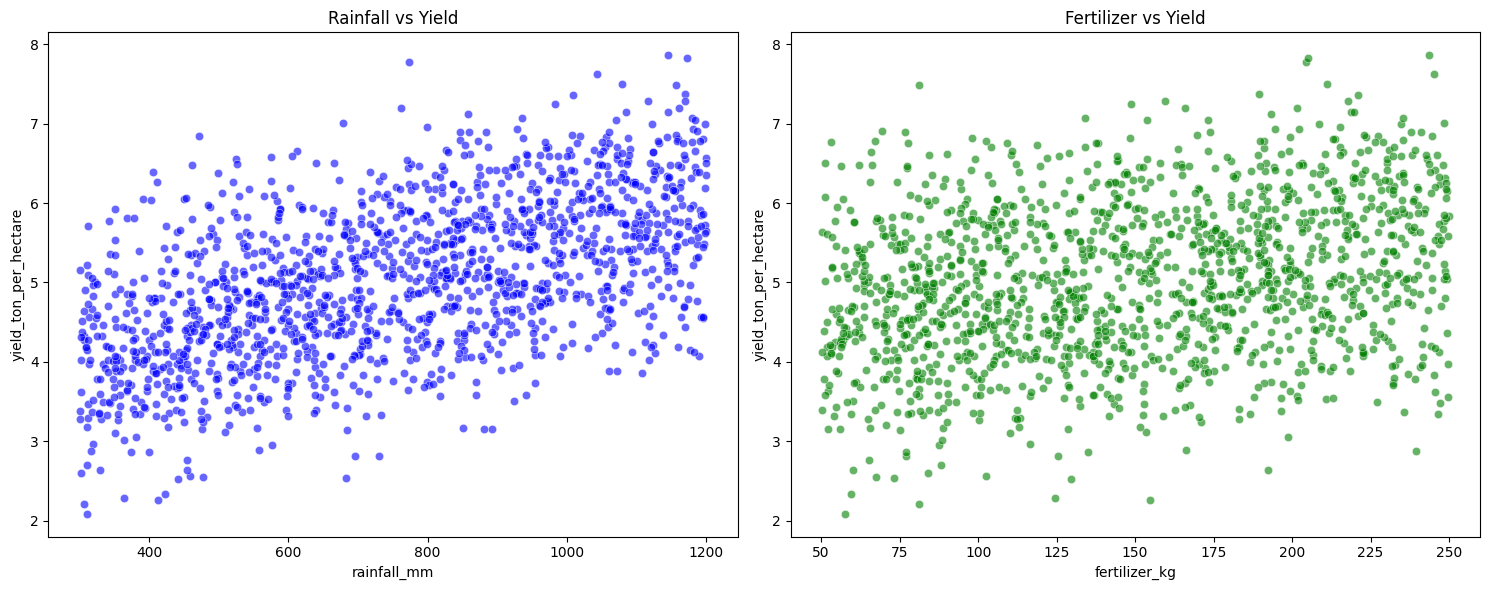



--- Q9: Correlation Analysis ---


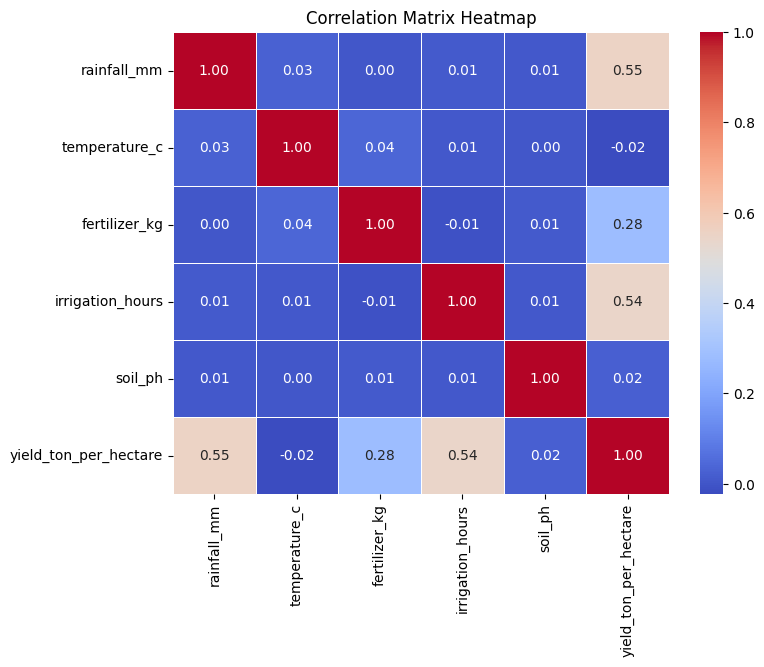

Top 3 features most correlated with yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


--- Q10: Group-Based Analysis ---
Average Yield by Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
Highest Average Yield Crop: Rice (5.49)

Average Yield by Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Highest Average Yield Soil: Loamy (5.37)


--- Q11: Feature Encoding ---
Categorical Columns Identified: ['crop_type', 'soil_type']

Transformed Dataset (First 5 rows):
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3        

In [2]:
# ==========================================
# Week 3 Assignment 1: Agricultural Yield EDA & ML
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ------------------------------------------
# Part A: Understanding the Dataset
# ------------------------------------------

# Q1. Dataset Overview
# (Loading the data and printing shape, names, and first 10 rows)
df = pd.read_csv('agriculture_yield_dataset.csv')

print("--- Q1: Dataset Overview ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("Column Names:", df.columns.tolist())
print("\nFirst 10 Records:")
print(df.head(10))
print("\n" + "="*50 + "\n")

# Q2. Data Types and Missing Values
print("--- Q2: Data Types and Missing Values ---")
print("Data Types:")
print(df.dtypes)
print("\nMissing Values per Column:")
missing_info = df.isnull().sum()
print(missing_info)
print("\n" + "="*50 + "\n")

# Q3. Descriptive Statistics
print("--- Q3: Descriptive Statistics ---")
num_stats = df.describe()
print(num_stats)

# Automatically extracting the highest mean and standard deviation
mean_series = num_stats.loc['mean']
std_series = num_stats.loc['std']
print(f"\nFeature with highest mean: {mean_series.idxmax()} ({mean_series.max():.2f})")
print(f"Feature with highest std dev: {std_series.idxmax()} ({std_series.max():.2f})")
print("\n" + "="*50 + "\n")


# ------------------------------------------
# Part B: Exploratory Data Analysis (EDA)
# ------------------------------------------

# Q4. Distribution Analysis
print("--- Q4: Distribution Analysis (Plots generating...) ---")
dist_features = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

plt.figure(figsize=(14, 10))
for i, col in enumerate(dist_features, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.histplot(df[col], kde=True, color='skyblue')
        plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()
print("\n" + "="*50 + "\n")

# Q5. Crop Type Analysis
print("--- Q5: Crop Type Analysis ---")
if 'crop_type' in df.columns:
    print("Crop Type Counts:")
    print(df['crop_type'].value_counts())

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='crop_type', order=df['crop_type'].value_counts().index, palette='viridis')
    plt.title('Count Plot of Crop Types')
    plt.xticks(rotation=45)
    plt.show()
print("\n" + "="*50 + "\n")

# Q6. Soil Type Analysis
print("--- Q6: Soil Type Analysis ---")
if 'soil_type' in df.columns:
    print("Soil Type Counts:")
    print(df['soil_type'].value_counts())

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='soil_type', order=df['soil_type'].value_counts().index, palette='magma')
    plt.title('Count Plot of Soil Types')
    plt.xticks(rotation=45)
    plt.show()
print("\n" + "="*50 + "\n")

# Q7. Yield Distribution
print("--- Q7: Yield Distribution ---")
if 'yield_ton_per_hectare' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df['yield_ton_per_hectare'], kde=True, color='salmon')
    plt.title('Detailed Distribution of Yield (Ton/Hectare)')
    plt.show()
print("\n" + "="*50 + "\n")

# Q8. Scatter Plot Analysis
print("--- Q8: Scatter Plot Analysis ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
if 'rainfall_mm' in df.columns and 'yield_ton_per_hectare' in df.columns:
    sns.scatterplot(data=df, x='rainfall_mm', y='yield_ton_per_hectare', ax=axes[0], alpha=0.6, color='blue')
    axes[0].set_title('Rainfall vs Yield')

if 'fertilizer_kg' in df.columns and 'yield_ton_per_hectare' in df.columns:
    sns.scatterplot(data=df, x='fertilizer_kg', y='yield_ton_per_hectare', ax=axes[1], alpha=0.6, color='green')
    axes[1].set_title('Fertilizer vs Yield')
plt.tight_layout()
plt.show()
print("\n" + "="*50 + "\n")

# Q9. Correlation Analysis
print("--- Q9: Correlation Analysis ---")
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

if 'yield_ton_per_hectare' in corr_matrix.columns:
    top_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').abs().nlargest(3)
    print("Top 3 features most correlated with yield:")
    print(top_corr)
print("\n" + "="*50 + "\n")

# Q10. Group-Based Analysis
print("--- Q10: Group-Based Analysis ---")
if 'crop_type' in df.columns and 'yield_ton_per_hectare' in df.columns:
    print("Average Yield by Crop Type:")
    crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
    print(crop_yield)
    print(f"Highest Average Yield Crop: {crop_yield.idxmax()} ({crop_yield.max():.2f})")

if 'soil_type' in df.columns and 'yield_ton_per_hectare' in df.columns:
    print("\nAverage Yield by Soil Type:")
    soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
    print(soil_yield)
    print(f"Highest Average Yield Soil: {soil_yield.idxmax()} ({soil_yield.max():.2f})")
print("\n" + "="*50 + "\n")


# ------------------------------------------
# Part C: Data Preparation
# ------------------------------------------

# Q11. Feature Encoding
print("--- Q11: Feature Encoding ---")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical Columns Identified: {categorical_cols}")

# One-Hot Encoding converts category text to columns of 1s and 0s
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nTransformed Dataset (First 5 rows):")
print(df_encoded.head())
print("\n" + "="*50 + "\n")

# Q12. Feature Selection
print("--- Q12: Feature Selection ---")
target_column = 'yield_ton_per_hectare'
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]
print(f"Target Variable: {target_column}")
print(f"Input Features Count: {X.shape[1]}")
print("\n" + "="*50 + "\n")


# ------------------------------------------
# Part D: Machine Learning
# ------------------------------------------

# Q13. Train-Test Split
print("--- Q13: Train-Test Split ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print("\n" + "="*50 + "\n")

# Q14. Linear Regression Model
print("--- Q14: Linear Regression Model ---")
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_:.4f}\n")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("Model Coefficients:")
print(coefficients.to_string(index=False))

highest_pos_coef = coefficients.loc[coefficients['Coefficient'].idxmax()]
print(f"\nFeature with highest positive coefficient: {highest_pos_coef['Feature']} ({highest_pos_coef['Coefficient']:.4f})")
print("\n" + "="*50 + "\n")

